# ChebKAN Spiral

In [9]:
import random

import matplotlib.pyplot as plt
import numpy as np

from IPython.display import display

from principia import mse_loss
from principia import AdamOptimiser
from principia import Sequential
from principia import Tensor
from principia import ChebLayer
from principia import RBFLayer

import time

In [10]:
def spiral_gen(n_points, noise, revolutions):
    angles = np.random.rand(n_points)
    angles = np.sqrt(angles)
    theta = angles * (revolutions * 2 * np.pi)

    r = theta
    
    X_a = r * np.cos(theta) + (np.random.randn(n_points) * noise)
    Y_a = r * np.sin(theta) + (np.random.randn(n_points) * noise)

    X_b = -r * np.cos(theta) + (np.random.randn(n_points) * noise)
    Y_b = -r * np.sin(theta) + (np.random.randn(n_points) * noise)

    coords_a = np.column_stack((X_a, Y_a))
    coords_b = np.column_stack((X_b, Y_b))

    coords = np.vstack((coords_a, coords_b))

    max_val = np.max(np.abs(coords))
    coords = coords / max_val

    zeros_array = np.zeros(n_points)
    ones_array = np.ones(n_points)

    labels = np.concatenate((zeros_array, ones_array))

    return coords,labels

In [11]:
def main(num_points=1000, noise=0.5, revolutions=3, learning_rate=0.01, epochs=1000, plot_interval=10, batch_size=500,show_plot=True):
    x, y = spiral_gen(num_points, noise, revolutions)

    indices = np.arange(len(x))
    np.random.shuffle(indices)
    x = x[indices]
    y = y[indices]

    x = Tensor(np.array(x))
    y = Tensor(np.array(y).reshape(-1, 1))

    model = Sequential([ChebLayer(2, 8, 6), ChebLayer(8, 8, 6), ChebLayer(8, 1, 6)])
    optimiser = AdamOptimiser(model.parameters(), learning_rate)

    xx = np.linspace(-1, 1, 50)
    yy = np.linspace(-1, 1, 50)
    xx_mesh, yy_mesh = np.meshgrid(xx, yy)
    input_mesh = np.stack([xx_mesh.flatten(), yy_mesh.flatten()], axis=1)
    input_tensor = Tensor(input_mesh)

    fig, ax = plt.subplots()
    ax.set_xlim(-1, 1)
    ax.set_ylim(-1, 1)
    ax.set_aspect("equal", adjustable="box")
    cbar = None

    plot_handle = display(fig, display_id=True)

    for i in range(1, epochs + 1):

        for j in range(0, len(x.data), batch_size):
            x_batch = Tensor(x.data[j:j+batch_size])
            y_batch = Tensor(y.data[j:j+batch_size])

            predictions = model(x_batch)
            mse = mse_loss(predictions, y_batch)

            model.zero_grad()
            mse.backward()
            optimiser.step()

        if i == 1 or i % plot_interval == 0:
            time_taken = time.time() - start
            time_taken = round(time_taken, 2)

            mesh_preds = model(input_tensor)

            final_map = mesh_preds.reshape((50, 50)).data

            if cbar is not None:
                cbar.remove()

            ax.clear()

            contour = ax.contourf(xx, yy, final_map, levels=20, vmin=0, vmax=1, cmap="coolwarm")
            ax.scatter(x.data[:, 0], x.data[:, 1], c=y.data.flatten(), cmap="bwr", edgecolors="black", alpha=0.5, s=20)
            
            cbar = fig.colorbar(contour, ax=ax, label='Network Output')
            
            ax.set_xlim(-1, 1)
            ax.set_ylim(-1, 1)
            ax.set_aspect("equal", adjustable="box")
            ax.set_title(f"ChebKAN Decision Boundary - Epoch {i}")

            plot_handle.update(fig) 
            print(f"EPOCH NUM:{i} LOSS:{mse.data} TIME:{time_taken}")

    plt.close(fig)

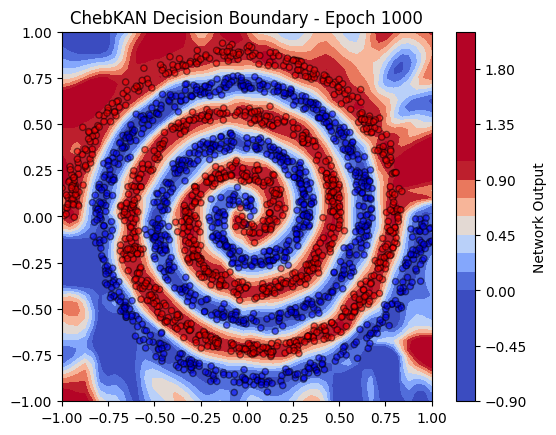

EPOCH NUM:1 LOSS:0.35725870728492737 TIME:0.09
EPOCH NUM:10 LOSS:0.22384744882583618 TIME:0.45
EPOCH NUM:20 LOSS:0.1008235365152359 TIME:0.81
EPOCH NUM:30 LOSS:0.04012412205338478 TIME:1.2
EPOCH NUM:40 LOSS:0.028913062065839767 TIME:1.54
EPOCH NUM:50 LOSS:0.021626608446240425 TIME:1.89
EPOCH NUM:60 LOSS:0.016246343031525612 TIME:2.24
EPOCH NUM:70 LOSS:0.012346983887255192 TIME:2.62
EPOCH NUM:80 LOSS:0.010423727333545685 TIME:3.12
EPOCH NUM:90 LOSS:0.009883614256978035 TIME:3.49
EPOCH NUM:100 LOSS:0.008750438690185547 TIME:3.87
EPOCH NUM:110 LOSS:0.008055963553488255 TIME:4.23
EPOCH NUM:120 LOSS:0.00828982051461935 TIME:4.61
EPOCH NUM:130 LOSS:0.007115832529962063 TIME:4.97
EPOCH NUM:140 LOSS:0.006793546956032515 TIME:5.33
EPOCH NUM:150 LOSS:0.006513544358313084 TIME:5.72
EPOCH NUM:160 LOSS:0.008156618103384972 TIME:6.24
EPOCH NUM:170 LOSS:0.00953487865626812 TIME:6.6
EPOCH NUM:180 LOSS:0.007236498408019543 TIME:6.97
EPOCH NUM:190 LOSS:0.0062924949452281 TIME:7.34
EPOCH NUM:200 LOSS:0.0

In [13]:
start = time.time()
main()